# Parts II/III: Labels and Leakage Tests (M3)

The target is the forward change of each surface cell,
`dIV(t, h) = IV(t+h) - IV(t)` for horizons of 5, 15, 30, and 60 minutes.
The future IV is taken by an **exact-timestamp join**: a horizon landing past
the close yields NaN and the row is dropped, never wrapped around. That join
is the only place the pipeline touches the future, which makes it the one
seam every leakage control below attacks.

This notebook runs on the June panel (21 gated sessions).

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The research library and data live in the (private) qfdev_research repo,
# checked out as a sibling of this showcase repo. Override with QFDEV_RESEARCH.
RESEARCH = os.path.abspath(os.environ.get('QFDEV_RESEARCH', '../../qfdev_research'))
assert os.path.isdir(os.path.join(RESEARCH, 'quant')), RESEARCH
sys.path.insert(0, RESEARCH)

plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.width', 160)

from quant.forecasting import config as C
from quant.forecasting.data import load_panel
from quant.forecasting.labels import add_forward_div_labels, label_columns
from quant.forecasting.splits import walk_forward_splits

SURFACE_ROOT = os.path.join(RESEARCH, 'quant', 'surface', 'out')
DAYS = sorted(os.path.basename(os.path.dirname(p)) for p in
              glob.glob(os.path.join(SURFACE_ROOT, 'spy_202606*', 'surface_state_1m.parquet')))
panel = load_panel(DAYS, SURFACE_ROOT)
panel = add_forward_div_labels(panel, C.HORIZONS_MIN)
print(f"{len(DAYS)} sessions | {len(panel):,} cell-minutes | horizons {C.HORIZONS_MIN}")

21 sessions | 897,532 cell-minutes | horizons (5, 15, 30, 60)


## Label distributions

IV is sticky at these horizons: most cells barely move, and the tails widen
with horizon. This is why persistence (dIV = 0) is a genuinely hard null and
why headline metrics are relative to it.

,count,mean,std,min,max
dIV_5m,885491.0,0.00033,0.01717,-0.56590,1.11483
dIV_15m,863274.0,0.00098,0.01943,-0.63062,1.06947
dIV_30m,830105.0,0.00195,0.02143,-0.51152,1.16508
dIV_60m,763881.0,0.00403,0.02573,-0.51862,0.96437


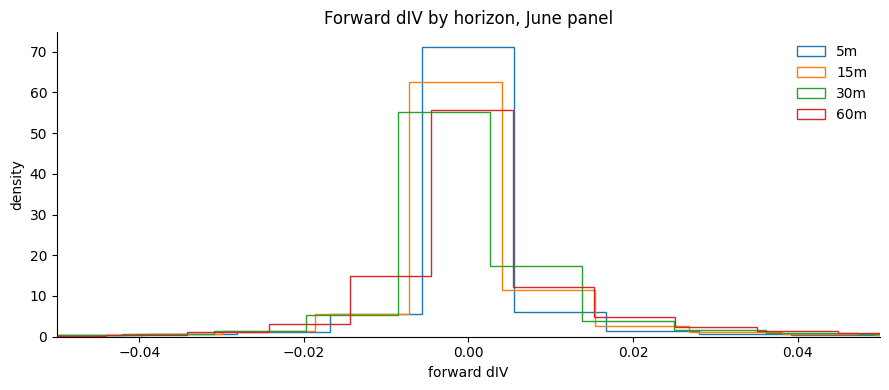

In [2]:
lab_cols = label_columns(C.HORIZONS_MIN)
display(panel[lab_cols].describe().T[['count', 'mean', 'std', 'min', 'max']].round(5))

fig, ax = plt.subplots(figsize=(9, 4))
for h in C.HORIZONS_MIN:
    s = panel[f'dIV_{h}m'].dropna()
    ax.hist(s, bins=150, histtype='step', density=True, label=f'{h}m')
ax.set_xlim(-0.05, 0.05); ax.set_xlabel('forward dIV'); ax.set_ylabel('density')
ax.set_title('Forward dIV by horizon, June panel')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

## Missingness is structural, not random

A 60-minute label cannot exist in the last hour of the session. Label
availability by time of day makes that explicit; models never see these rows
for the affected horizon.

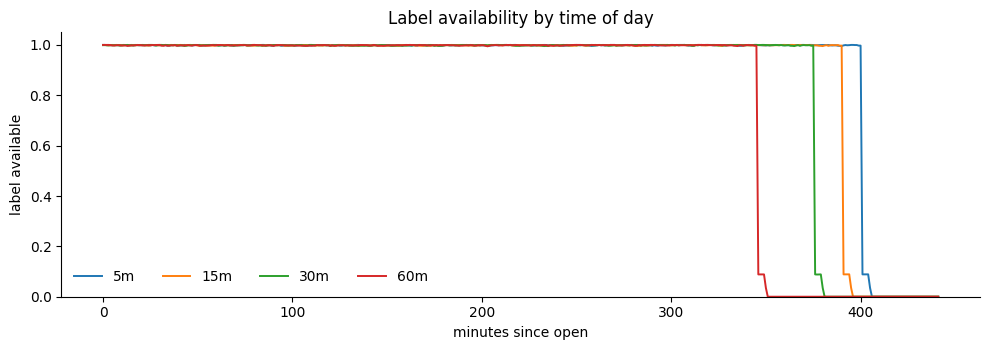

In [3]:
avail = (panel.assign(tod=panel['minutes_since_open'])
         .groupby('tod')[lab_cols].apply(lambda g: g.notna().mean()))
fig, ax = plt.subplots(figsize=(10, 3.6))
for h in C.HORIZONS_MIN:
    ax.plot(avail.index, avail[f'dIV_{h}m'], label=f'{h}m', lw=1.4)
ax.set_xlabel('minutes since open'); ax.set_ylabel('label available')
ax.set_ylim(0, 1.05); ax.legend(frameon=False, ncol=4)
ax.set_title('Label availability by time of day')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

## Purged walk-forward

Five expanding-window folds over the minute axis, with an embargo equal to
the longest horizon (60 minutes) between train and test so overlapping labels
cannot straddle the boundary. Standardization is always fit on train folds
only.

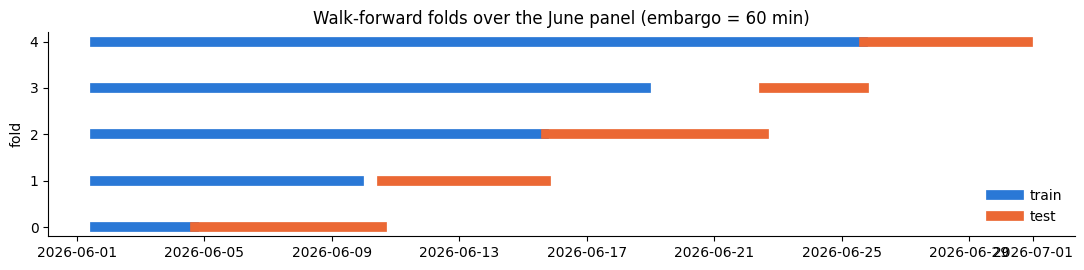

In [4]:
folds = list(walk_forward_splits(panel['minute'], C.N_SPLITS, C.EMBARGO_MIN))
fig, ax = plt.subplots(figsize=(11, 2.8))
for i, (tr, te) in enumerate(folds):
    ax.plot([tr.min(), tr.max()], [i, i], lw=7, color='#2a78d6',
            label='train' if i == 0 else None)
    ax.plot([te.min(), te.max()], [i, i], lw=7, color='#eb6834',
            label='test' if i == 0 else None)
ax.set_yticks(range(len(folds))); ax.set_ylabel('fold')
ax.set_title(f'Walk-forward folds over the June panel (embargo = {C.EMBARGO_MIN} min)')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

## Mechanical leakage probes

Two probes run against the feature builder itself, not against model output:

1. **Truncation invariance**: features computed on a panel cut at time `t`
   must be bitwise identical to the same features from the full-panel build.
2. **Future-input perturbation**: corrupting all raw inputs after `t` must
   leave features at or before `t` unchanged.

The probes were validated by deliberately injecting a future-IV feature,
which both caught. They run as part of the registered baseline harness
(`leak_probes.py`).

## Shuffled-label negative control

Within each fold, **training** labels are permuted after the purge/embargo
(test labels intact) and every model class is retrained. A leak-free harness
must collapse learned skill to the level of a label-only baseline. One
subtlety that matters: the target has non-zero mean over long windows, so
shuffled models are judged against a **constant train-mean baseline**, not
the zero null; otherwise target drift masquerades as leakage. The registered
results (recorded in FINDINGS.md, MLflow run c1fc628f):

,panel,max feature excess over mean-null,tolerance,real-label skill range
0,June (21 sessions),0.0041,0.02,+0.17 to +0.31
1,3-month (64 sessions),0.0010,0.02,+0.24 to +0.40


Drift subtlety, 60m ridge: naive shuffle skill vs the zero null read +0.026,
but the constant train-mean null itself scores +0.022; genuine feature excess +0.004.


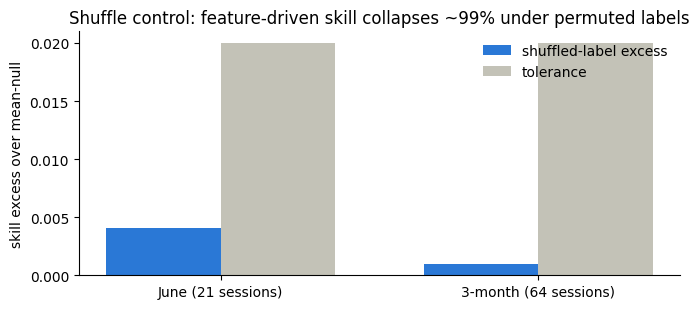

In [5]:
ctl = pd.DataFrame({
    'panel': ['June (21 sessions)', '3-month (64 sessions)'],
    'max feature excess over mean-null': [0.0041, 0.0010],
    'tolerance': [0.02, 0.02],
    'real-label skill range': ['+0.17 to +0.31', '+0.24 to +0.40'],
})
display(ctl)

fig, ax = plt.subplots(figsize=(7, 3.2))
x = np.arange(2)
ax.bar(x - 0.18, [0.0041, 0.0010], 0.36, label='shuffled-label excess', color='#2a78d6')
ax.bar(x + 0.18, [0.02, 0.02], 0.36, label='tolerance', color='#c3c2b7')
ax.set_xticks(x, ctl['panel']); ax.set_ylabel('skill excess over mean-null')
ax.set_title('Shuffle control: feature-driven skill collapses ~99% under permuted labels')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
print('Drift subtlety, 60m ridge: naive shuffle skill vs the zero null read +0.026,')
print('but the constant train-mean null itself scores +0.022; genuine feature excess +0.004.')

The control doubles as the explicit Part I leakage audit: if the surface
builder or feature layer smuggled future information, the shuffled models
would retain skill. They do not, and feature importances go flat under
shuffling (top gain share 6.6% vs 12 to 13% on real labels).